# 1. Data Collections

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

df.head()


Saving BIG DATA.xlsx to BIG DATA.xlsx


,Judul,Terjual,Harga,Nama,Rating,Review
0,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,A***d,4,"pengiriman cepat, penjual fast response dan pr..."
1,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,anggaydstr,5,"Kalap karena diskon. Pengemasan baik, tebel bu..."
2,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,M***d,5,Kualitas bagus. Hasil cetakan rapi. Tulisan te...
3,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Ashrofa,5,buku ori karena dari gramed. super duper murah...
4,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Herdinastiti,5,"Bukunya Ori bagus , packing aman banget, pengi..."


# 2. Text Procesing

In [ ]:
!pip install Sastrawi openpyxl
data = df

import nltk
nltk.download('all')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.2 MB/s eta 0:00:00


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
data['Review'] = data['Review'].astype(str)
data['Review'] = data['Review'].str.lower()
data

import string
import re
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

def remove_links(text):

    text = text.replace('\\t'," ").replace('\\n'," ").replace('\\u'," ").replace('\\',"")

    text = text.encode('ascii', 'replace').decode('ascii')

    text = ' '.join(re.sub("([@#][A-Za-z0-9]+)|(\w+:\/\/\S+)"," ", text).split())

    return text.replace("http://", " ").replace("https://", " ")

data['Review'] = data['Review'].apply(remove_links)

def remove_number(text):
    return  re.sub(r"\d+", " ", text)

data['Review'] = data['Review'].apply(remove_number)

def remove_punctuation(text):
    return text.translate(str.maketrans("","",string.punctuation))

data['Review'] = data['Review'].apply(remove_punctuation)


def remove_singl_char(text):
    return re.sub(r"\b[a-zA-Z]\b", " ", text)

data['Review'] = data['Review'].apply(remove_singl_char)

def word_tokenize_wrapper(text):
    return word_tokenize(text)

data['Review_tokenize'] = data['Review'].apply(word_tokenize_wrapper)
data

,Judul,Terjual,Harga,Nama,Rating,Review,Review_tokenize
0,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,A***d,4,pengiriman cepat penjual fast response dan pro...,"[pengiriman, cepat, penjual, fast, response, d..."
1,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,anggaydstr,5,kalap karena diskon pengemasan baik tebel bubb...,"[kalap, karena, diskon, pengemasan, baik, tebe..."
2,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,M***d,5,kualitas bagus hasil cetakan rapi tulisan terb...,"[kualitas, bagus, hasil, cetakan, rapi, tulisa..."
3,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Ashrofa,5,buku ori karena dari gramed super duper murah ...,"[buku, ori, karena, dari, gramed, super, duper..."
4,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Herdinastiti,5,bukunya ori bagus packing aman banget pengiri...,"[bukunya, ori, bagus, packing, aman, banget, p..."
...,...,...,...,...,...,...,...
2716,You Do You: Discovering Life through Experimen...,5 rb+,128000,Steven,5,bagus,[bagus]
2717,You Do You: Discovering Life through Experimen...,5 rb+,128000,Fauzi,5,original,[original]
2718,You Do You: Discovering Life through Experimen...,5 rb+,128000,U***l,5,diterima dengan baik many thanks,"[diterima, dengan, baik, many, thanks]"
2719,You Do You: Discovering Life through Experimen...,5 rb+,128000,Adrian,5,kali aja di baca koh ruby tks koh,"[kali, aja, di, baca, koh, ruby, tks, koh]"


In [ ]:

def freqDist_wrapper(text):
    return FreqDist(text)

Ulasan_fqsist = data['Review_tokenize'].apply(freqDist_wrapper)

print('Frequency Tokens : \n')
print(Ulasan_fqsist.head().apply(lambda x : x.most_common()))


slank_word_dict = {
    "keduakali" : "kedua kali",
    "agak" : "sedikit",
    "pas" : "saat",
    "produkx" : "produknya",
    "sukamkasih" : "suka makasih",
    "gak" : "tidak",
    "cpt" : "cepat",
    "sdh" : "sudah",
    "recommend" : "rekomendasi",
    "bagusseller" : "bagus",
    "bagusssss" : "bagus",
    "bagussssss" : "bagus",
    "baguuussss" : "bagus",
    "cepatmakasih": "cepat",
    "cepatmantappp": "cepat",
    "cepatproduct": "cepat",
    "cepatrecomended": "cepat",
    "cepattoko": "cepat",
    "recomended": "rekomendasi",
    "recommended": "rekomendasi",
    "rekomendasi": "rekomendasi",
    "rekomended": "rekomendasi",
    }


def slank_normalized_term(document):
    return [slank_word_dict[term] if term in slank_word_dict else term for term in document]

Frequency Tokens : 

0    [(pengiriman, 1), (cepat, 1), (penjual, 1), (f...
1    [(kalap, 1), (karena, 1), (diskon, 1), (pengem...
2    [(kualitas, 1), (bagus, 1), (hasil, 1), (cetak...
3    [(buku, 2), (karena, 2), (ori, 1), (dari, 1), ...
4    [(bukunya, 1), (ori, 1), (bagus, 1), (packing,...
Name: Review_tokenize, dtype: object


In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
nltk.download('punkt')

kamus_alay_1 = pd.read_csv(
    "https://raw.githubusercontent.com/ramaprakoso/analisis-sentimen/master/kamus/kbba.txt",
    delimiter="\t",
    header=None,
    names=['slang', 'formal'])

kamus_alay_2 = pd.read_csv(
    "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv",
    usecols=["slang", "formal"])

kamus_alay = pd.concat([kamus_alay_1, kamus_alay_2], ignore_index=True)

normalized_word_dict = {row['slang']: row['formal'] for _, row in kamus_alay.iterrows()}

stop_words = set(stopwords.words('indonesian'))
stop_words.update(['nya'])

def normalize_and_remove_stopwords(document):
    normalized = [normalized_word_dict.get(term, term) for term in document]
    filtered = [term for term in normalized if term not in stop_words]
    return filtered

data['Review_tokenize'] = data['Review'].str.lower().apply(word_tokenize)
data['Review_normalized'] = data['Review_tokenize'].apply(normalize_and_remove_stopwords)

data


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Judul,Terjual,Harga,Nama,Rating,Review,Review_tokenize,Review_normalized
0,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,A***d,4,pengiriman cepat penjual fast response dan pro...,"[pengiriman, cepat, penjual, fast, response, d...","[pengiriman, cepat, penjual, fast, response, p..."
1,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,anggaydstr,5,kalap karena diskon pengemasan baik tebel bubb...,"[kalap, karena, diskon, pengemasan, baik, tebe...","[kalap, diskon, pengemasan, tebal, bubblewrap,..."
2,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,M***d,5,kualitas bagus hasil cetakan rapi tulisan terb...,"[kualitas, bagus, hasil, cetakan, rapi, tulisa...","[kualitas, bagus, hasil, cetakan, rapi, tulisa..."
3,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Ashrofa,5,buku ori karena dari gramed super duper murah ...,"[buku, ori, karena, dari, gramed, super, duper...","[buku, orisinal, gramed, super, duper, murah, ..."
4,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Herdinastiti,5,bukunya ori bagus packing aman banget pengiri...,"[bukunya, ori, bagus, packing, aman, banget, p...","[bukunya, orisinal, bagus, packing, aman, bang..."
...,...,...,...,...,...,...,...,...
2716,You Do You: Discovering Life through Experimen...,5 rb+,128000,Steven,5,bagus,[bagus],[bagus]
2717,You Do You: Discovering Life through Experimen...,5 rb+,128000,Fauzi,5,original,[original],[original]
2718,You Do You: Discovering Life through Experimen...,5 rb+,128000,U***l,5,diterima dengan baik many thanks,"[diterima, dengan, baik, many, thanks]","[diterima, many, terima kasih]"
2719,You Do You: Discovering Life through Experimen...,5 rb+,128000,Adrian,5,kali aja di baca koh ruby tks koh,"[kali, aja, di, baca, koh, ruby, tks, koh]","[kali, baca, koh, ruby, terima kasih, koh]"


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_text(words):
    return [stemmer.stem(word) for word in words]

data['Review_stemmed'] = data['Review_normalized'].apply(stemming_text)

data


,Judul,Terjual,Harga,Nama,Rating,Review,Review_tokenize,Review_normalized,Review_stemmed
0,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,A***d,4,pengiriman cepat penjual fast response dan pro...,"[pengiriman, cepat, penjual, fast, response, d...","[pengiriman, cepat, penjual, fast, response, p...","[kirim, cepat, jual, fast, response, produk, b..."
1,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,anggaydstr,5,kalap karena diskon pengemasan baik tebel bubb...,"[kalap, karena, diskon, pengemasan, baik, tebe...","[kalap, diskon, pengemasan, tebal, bubblewrap,...","[kalap, diskon, emas, tebal, bubblewrap, aman,..."
2,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,M***d,5,kualitas bagus hasil cetakan rapi tulisan terb...,"[kualitas, bagus, hasil, cetakan, rapi, tulisa...","[kualitas, bagus, hasil, cetakan, rapi, tulisa...","[kualitas, bagus, hasil, cetak, rapi, tulis, b..."
3,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Ashrofa,5,buku ori karena dari gramed super duper murah ...,"[buku, ori, karena, dari, gramed, super, duper...","[buku, orisinal, gramed, super, duper, murah, ...","[buku, orisinal, gramed, super, duper, murah, ..."
4,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Herdinastiti,5,bukunya ori bagus packing aman banget pengiri...,"[bukunya, ori, bagus, packing, aman, banget, p...","[bukunya, orisinal, bagus, packing, aman, bang...","[buku, orisinal, bagus, packing, aman, banget,..."
...,...,...,...,...,...,...,...,...,...
2716,You Do You: Discovering Life through Experimen...,5 rb+,128000,Steven,5,bagus,[bagus],[bagus],[bagus]
2717,You Do You: Discovering Life through Experimen...,5 rb+,128000,Fauzi,5,original,[original],[original],[original]
2718,You Do You: Discovering Life through Experimen...,5 rb+,128000,U***l,5,diterima dengan baik many thanks,"[diterima, dengan, baik, many, thanks]","[diterima, many, terima kasih]","[terima, many, terima kasih]"
2719,You Do You: Discovering Life through Experimen...,5 rb+,128000,Adrian,5,kali aja di baca koh ruby tks koh,"[kali, aja, di, baca, koh, ruby, tks, koh]","[kali, baca, koh, ruby, terima kasih, koh]","[kali, baca, koh, ruby, terima kasih, koh]"


In [ ]:
data["Review_clean"] = [' '.join(map(str, l)) for l in data['Review_stemmed']]
data

,Judul,Terjual,Harga,Nama,Rating,Review,Review_tokenize,Review_normalized,Review_stemmed,Review_clean
0,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,A***d,4,pengiriman cepat penjual fast response dan pro...,"[pengiriman, cepat, penjual, fast, response, d...","[pengiriman, cepat, penjual, fast, response, p...","[kirim, cepat, jual, fast, response, produk, b...",kirim cepat jual fast response produk buku ori...
1,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,anggaydstr,5,kalap karena diskon pengemasan baik tebel bubb...,"[kalap, karena, diskon, pengemasan, baik, tebe...","[kalap, diskon, pengemasan, tebal, bubblewrap,...","[kalap, diskon, emas, tebal, bubblewrap, aman,...",kalap diskon emas tebal bubblewrap aman novel ...
2,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,M***d,5,kualitas bagus hasil cetakan rapi tulisan terb...,"[kualitas, bagus, hasil, cetakan, rapi, tulisa...","[kualitas, bagus, hasil, cetakan, rapi, tulisa...","[kualitas, bagus, hasil, cetak, rapi, tulis, b...",kualitas bagus hasil cetak rapi tulis baca bay...
3,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Ashrofa,5,buku ori karena dari gramed super duper murah ...,"[buku, ori, karena, dari, gramed, super, duper...","[buku, orisinal, gramed, super, duper, murah, ...","[buku, orisinal, gramed, super, duper, murah, ...",buku orisinal gramed super duper murah promo b...
4,Atomic Habits: Perubahan Kecil yang Memberikan...,10 rb+,108000,Herdinastiti,5,bukunya ori bagus packing aman banget pengiri...,"[bukunya, ori, bagus, packing, aman, banget, p...","[bukunya, orisinal, bagus, packing, aman, bang...","[buku, orisinal, bagus, packing, aman, banget,...",buku orisinal bagus packing aman banget kirim ...
...,...,...,...,...,...,...,...,...,...,...
2716,You Do You: Discovering Life through Experimen...,5 rb+,128000,Steven,5,bagus,[bagus],[bagus],[bagus],bagus
2717,You Do You: Discovering Life through Experimen...,5 rb+,128000,Fauzi,5,original,[original],[original],[original],original
2718,You Do You: Discovering Life through Experimen...,5 rb+,128000,U***l,5,diterima dengan baik many thanks,"[diterima, dengan, baik, many, thanks]","[diterima, many, terima kasih]","[terima, many, terima kasih]",terima many terima kasih
2719,You Do You: Discovering Life through Experimen...,5 rb+,128000,Adrian,5,kali aja di baca koh ruby tks koh,"[kali, aja, di, baca, koh, ruby, tks, koh]","[kali, baca, koh, ruby, terima kasih, koh]","[kali, baca, koh, ruby, terima kasih, koh]",kali baca koh ruby terima kasih koh


# 3. Eksplorasi Awal dan Statistik Deskriptif

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2721 entries, 0 to 2720
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Judul              2721 non-null   object
 1   Terjual            2721 non-null   object
 2   Harga              2721 non-null   int64 
 3   Nama               2721 non-null   object
 4   Rating             2721 non-null   int64 
 5   Review             2721 non-null   object
 6   Review_tokenize    2721 non-null   object
 7   Review_normalized  2721 non-null   object
 8   Review_stemmed     2721 non-null   object
 9   Review_clean       2721 non-null   object
dtypes: int64(2), object(8)
memory usage: 212.7+ KB

Kolom yang tersedia: ['Judul', 'Terjual', 'Harga', 'Nama', 'Rating', 'Review', 'Review_tokenize', 'Review_normalized', 'Review_stemmed', 'Review_clean']

Rata-rata panjang review: 66.07350238882763
Median panjang review: 55.0
Modus panjang review: 5
Standar deviasi panjang re

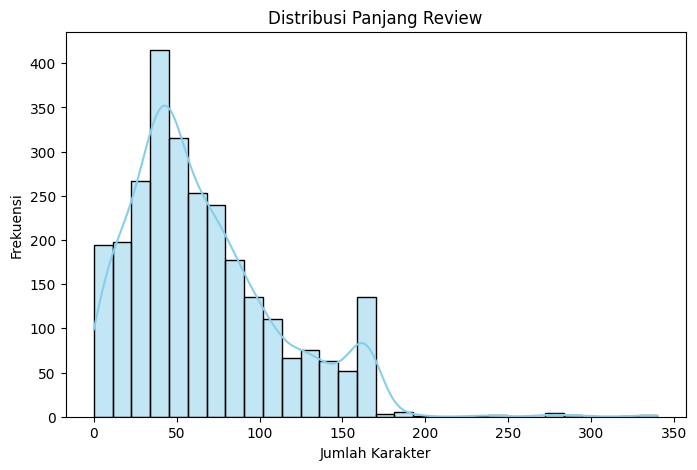

In [ ]:
df.info()
df.describe(include='all')
print("\nKolom yang tersedia:", df.columns.tolist())

df['Review_length'] = df['Review'].astype(str).apply(len)
print("\nRata-rata panjang review:", df['Review_length'].mean())
print("Median panjang review:", df['Review_length'].median())
print("Modus panjang review:", df['Review_length'].mode()[0])
print("Standar deviasi panjang review:", df['Review_length'].std())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Review_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

# 4. Visualisasi Data

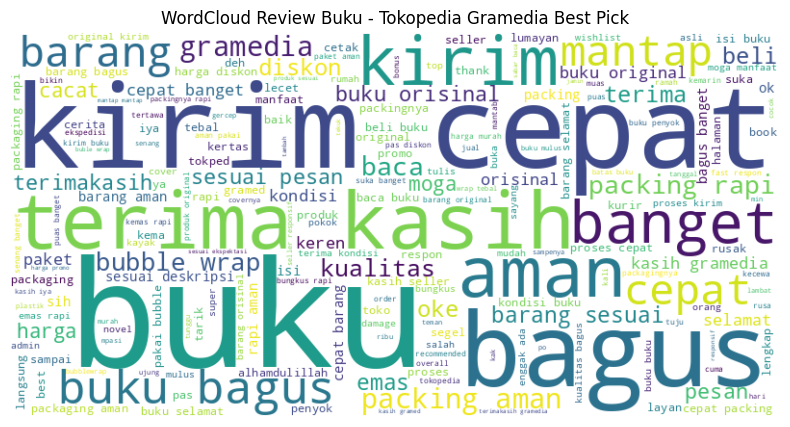

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud
import matplotlib.pyplot as plt

stopword_factory = StopWordRemoverFactory()
default_stopwords = stopword_factory.get_stop_words()
custom_stopwords = ['banget', 'aja', 'dong', 'deh', 'sih', 'nih', 'ya', 'kok', 'loh', 'nya']
all_stopwords = set(default_stopwords + custom_stopwords)

stemmer = StemmerFactory().create_stemmer()

all_text = ' '.join(df['Review_clean'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Review Buku - Tokopedia Gramedia Best Pick")
plt.show()


20 Kata paling sering muncul:
[('buku', 1224), ('cepat', 834), ('kirim', 826), ('bagus', 686), ('aman', 602), ('barang', 486), ('terima', 478), ('kasih', 387), ('packing', 373), ('banget', 371), ('rapi', 348), ('sesuai', 282), ('gramedia', 226), ('baca', 186), ('original', 179), ('orisinal', 174), ('pesan', 173), ('mantap', 168), ('diskon', 167), ('beli', 160)]


<Axes: title={'center': '20 Kata Terbanyak dalam Review'}, xlabel='Samples', ylabel='Counts'>

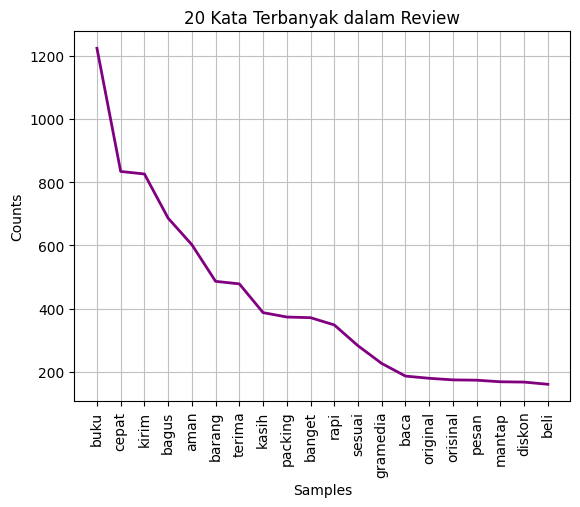

In [ ]:
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize

all_tokens = word_tokenize(' '.join(df['Review_clean']))

fdist = FreqDist(all_tokens)

print("\n20 Kata paling sering muncul:")
print(fdist.most_common(20))

fdist.plot(20, title='20 Kata Terbanyak dalam Review', color='purple')


# 5. Korelasi dan Pola

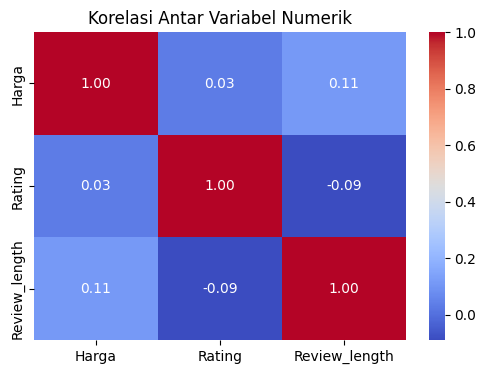

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Antar Variabel Numerik")
plt.show()


# 6. Label Sentimen

In [ ]:

positive_words = ['bagus', 'mantap', 'puas', 'cepat', 'rekomendasi', 'baik', 'murah', 'aman', 'original']
negative_words = [
    'jelek', 'lama', 'rusak', 'buruk', 'mengecewakan', 'parah',
    'salah', 'rumit', 'gagal', 'tidak sesuai', 'tidak cocok',
    'penipuan', 'hancur', 'penyok', 'sobek', 'robek', 'kotor', 'lecet', 'bekas', 'remuk', 'pudar',
    'cacat', 'tidak lengkap', 'tidak layak', 'bau', 'baret',
    'berdebu', 'tidak rapi', 'terlipat', 'kusut', 'bocor',
    'bercak', 'ngaret', 'tidak dibungkus', 'kemasan buruk',
    'tidak aman', 'tidak seperti deskripsi', 'asal-asalan',
    'tidak diproteksi', 'tidak dibalut', 'tidak dibungkus bubble wrap',
    'bubble wrap tipis', 'tidak sesuai ekspektasi', 'tidak profesional',
    'packing buruk', 'packing asal', 'halaman sobek', 'isi salah',
    'halaman hilang', 'sampul rusak', 'proses lambat', 'tidak responsif',
    'lama dikirim', 'tidak jelas'
]


def get_sentiment(text):
    pos, neg = 0, 0
    for word in text.split():
        if word in positive_words:
            pos += 1
        elif word in negative_words:
            neg += 1
    if pos > neg:
        return 'positif'
    elif neg > pos:
        return 'negatif'
    else:
        return 'netral'

df['Sentiment'] = df['Review_clean'].apply(get_sentiment)
df[['Review', 'Sentiment']].head()


,Review,Sentiment
0,pengiriman cepat penjual fast response dan pro...,positif
1,kalap karena diskon pengemasan baik tebel bubb...,positif
2,kualitas bagus hasil cetakan rapi tulisan terb...,positif
3,buku ori karena dari gramed super duper murah ...,positif
4,bukunya ori bagus packing aman banget pengiri...,positif


<ipython-input-13-7e2055a7aced>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', order=df['Sentiment'].value_counts().index, palette="viridis")


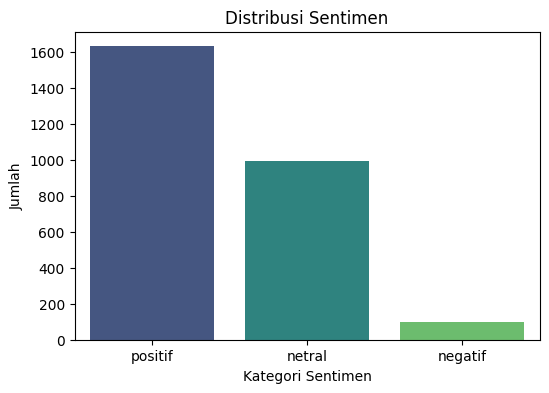

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment', order=df['Sentiment'].value_counts().index, palette="viridis")
plt.title("Distribusi Sentimen")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah")
plt.show()


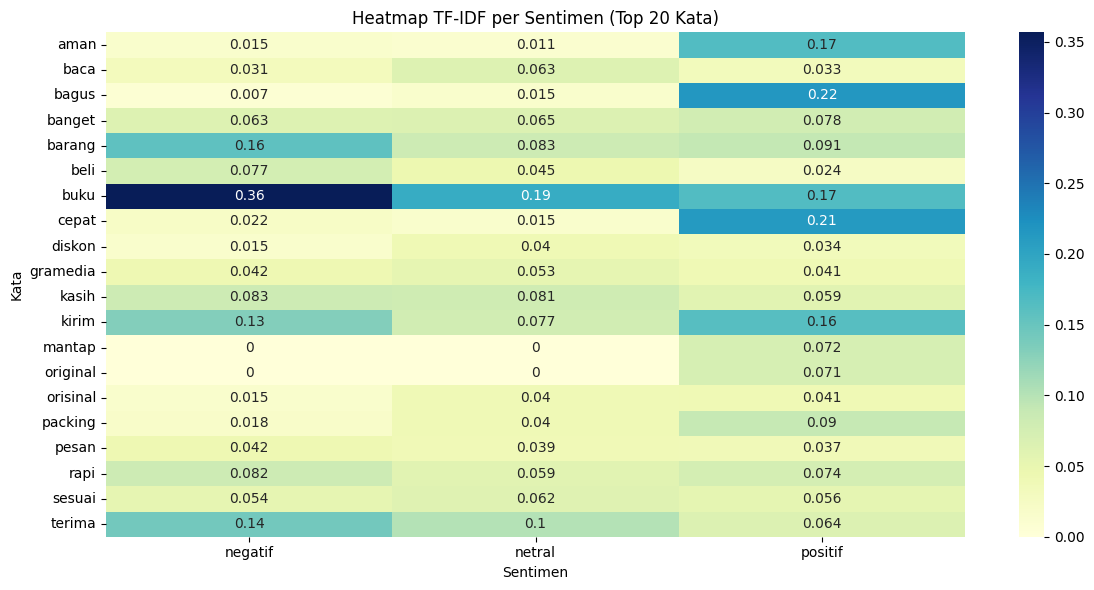

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns


tfidf = TfidfVectorizer(max_features=20)
X_tfidf = tfidf.fit_transform(df['Review_clean']).toarray()
tfidf_df = pd.DataFrame(X_tfidf, columns=tfidf.get_feature_names_out())


tfidf_df['Sentiment'] = df['Sentiment']

mean_by_sentiment = tfidf_df.groupby('Sentiment').mean()

plt.figure(figsize=(12,6))
sns.heatmap(mean_by_sentiment.T, cmap='YlGnBu', annot=True)
plt.title("Heatmap TF-IDF per Sentimen (Top 20 Kata)")
plt.xlabel("Sentimen")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

# **7. Penerapan Model**


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import DBSCAN

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Review_clean']).toarray()
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

results = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='weighted', zero_division=0)
    rec = recall_score(y_te, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_te, preds, average='weighted', zero_division=0)
    print(f"\n=== {name} Evaluation ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}\n")
    print(classification_report(y_te, preds, zero_division=0))
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
evaluate_model("Decision Tree", dt_model, X_train, X_test, y_train, y_test)

# 2. Support Vector Machine (SVM)
svm_model = SVC(kernel='linear', probability=True, random_state=42)
evaluate_model("Support Vector Machine", svm_model, X_train, X_test, y_train, y_test)

# 3. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
evaluate_model("K-Nearest Neighbors", knn_model, X_train, X_test, y_train, y_test)

# 4. Naive Bayes (Multinomial)
bayes_model = MultinomialNB()
evaluate_model("Naive Bayes", bayes_model, X_train, X_test, y_train, y_test)

# 5. Artificial Neural Network (ANN)
ann_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
evaluate_model("Artificial Neural Network", ann_model, X_train, X_test, y_train, y_test)

# Summary of classification metrics
results_df = pd.DataFrame(results)
print("\n=== Summary of Model Performance ===")
print(results_df)


=== Decision Tree Evaluation ===
Accuracy : 0.9688
Precision: 0.9690
Recall   : 0.9688
F1 Score : 0.9687

              precision    recall  f1-score   support

     negatif       0.94      0.84      0.89        19
      netral       0.95      0.97      0.96       199
     positif       0.98      0.98      0.98       327

    accuracy                           0.97       545
   macro avg       0.96      0.93      0.94       545
weighted avg       0.97      0.97      0.97       545


=== Support Vector Machine Evaluation ===
Accuracy : 0.9596
Precision: 0.9581
Recall   : 0.9596
F1 Score : 0.9565

              precision    recall  f1-score   support

     negatif       0.80      0.42      0.55        19
      netral       0.92      0.97      0.95       199
     positif       0.99      0.98      0.99       327

    accuracy                           0.96       545
   macro avg       0.90      0.79      0.83       545
weighted avg       0.96      0.96      0.96       545


=== K-Nearest 

=== Decision Tree Performance ===
Accuracy : 0.9688
Precision: 0.9690
Recall   : 0.9688
F1-score : 0.9687

              precision    recall  f1-score   support

     negatif       0.94      0.84      0.89        19
      netral       0.95      0.97      0.96       199
     positif       0.98      0.98      0.98       327

    accuracy                           0.97       545
   macro avg       0.96      0.93      0.94       545
weighted avg       0.97      0.97      0.97       545



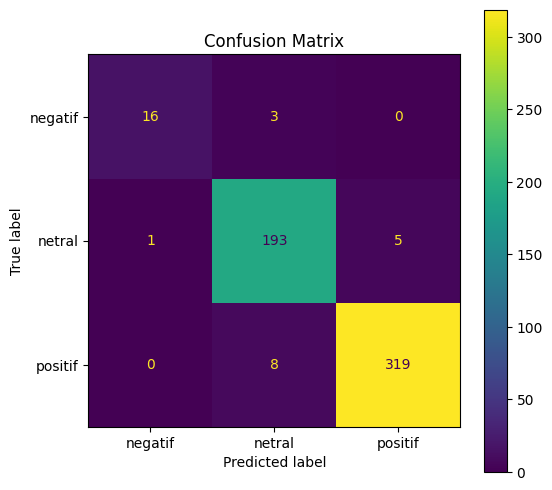

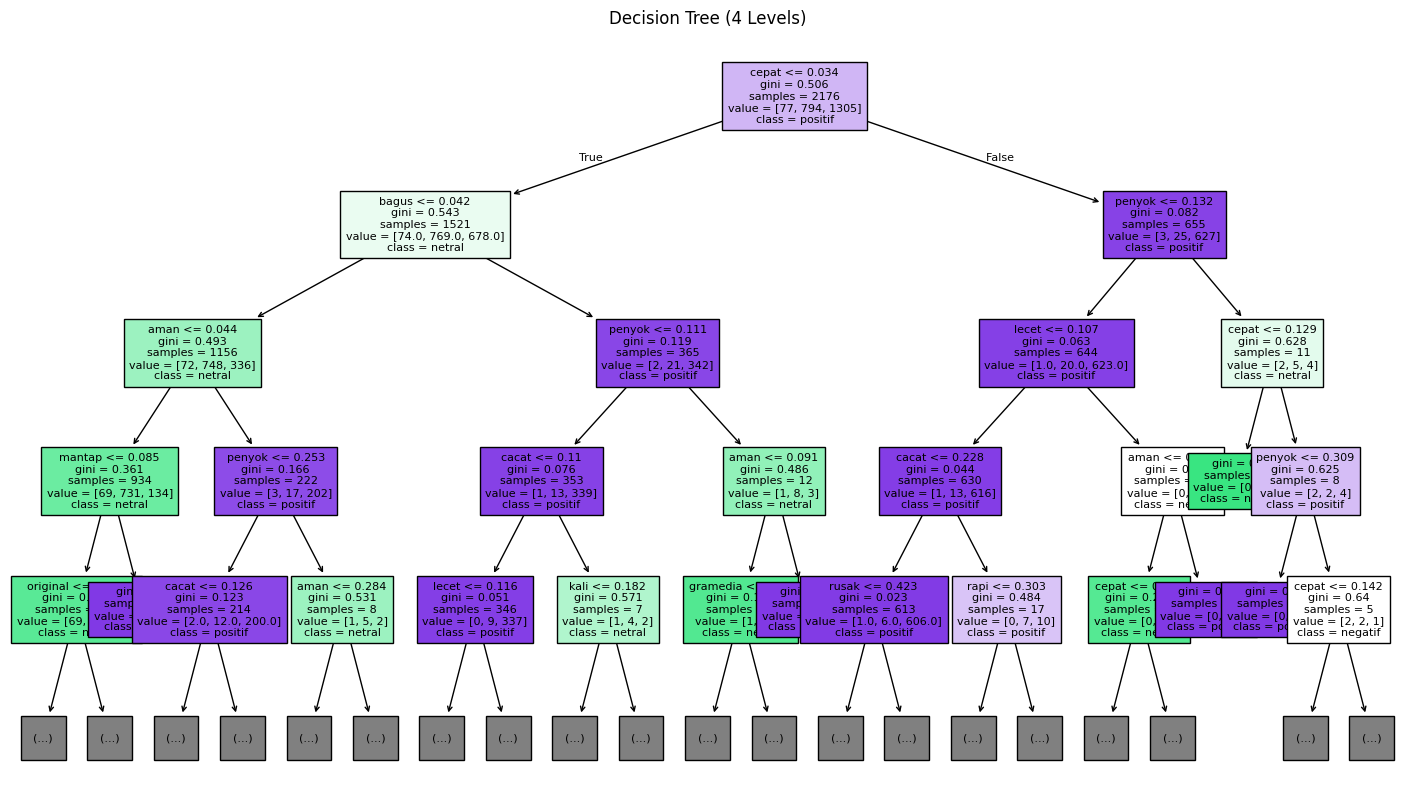

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df = df

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['Review_clean']).toarray()
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("=== Decision Tree Performance ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

# Visualisasi Pohon Keputusan (4 tingkat pertama)
fig, ax = plt.subplots(figsize=(18,10))
plot_tree(
    dt,
    max_depth=4,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=dt.classes_,
    filled=True,
    fontsize=8,
    ax=ax
)
plt.title('Decision Tree (4 Levels)')
plt.show()

In [ ]:
!pip install joblib
import joblib

joblib.dump(dt, 'decision_tree_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

# **8. Mencoba Model**

In [ ]:
dt_model = joblib.load('decision_tree_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

In [ ]:
import re
import string
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
import nltk

stop_words = set(stopwords.words('indonesian'))
stop_words.update(['nya', 'banget', 'aja', 'dong', 'deh', 'sih', 'nih', 'ya', 'kok', 'loh'])

slank_word_dict = {
    "gak": "tidak", "cpt": "cepat", "produkx": "produknya", "bagusssss": "bagus",
    "recommend": "rekomendasi", "cepatmantappp": "cepat"
}


stemmer = StemmerFactory().create_stemmer()


In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www.\S+", " ", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\b[a-zA-Z]\b", "", text)
    tokens = word_tokenize(text)
    tokens = [slank_word_dict.get(word, word) for word in tokens]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return tokens

In [ ]:
new_comment = "buku Keajaiban Toko Kelontong Namiya ini tidak dikirim. iya memang salah saya tidak video unboxing dan terlanjur klik Pesanan Selesai. tapi sayang sekali Gramedia sampai lalai tidak mengirim satu buku dan jadinya tidak bisa refund apalagi dikirim menyusul 🙏 mohon lain kali dicek barangnya dan dikabari ke pembeli jika tidak lengkap. jangan tunggu kami komplain. dana yang terpaksa direlakan semoga berkah"
processed_tokens = preprocess(new_comment)
processed_text = ' '.join(processed_tokens)
tfidf_input = vectorizer.transform([processed_text])
predicted_sentiment = dt_model.predict(tfidf_input)[0]
print("Komentar                   :", new_comment)
print("Komentar Setelah Preproses :", processed_text)
print("Sentimen                   :", predicted_sentiment)


Komentar                   : buku Keajaiban Toko Kelontong Namiya ini tidak dikirim. iya memang salah saya tidak video unboxing dan terlanjur klik Pesanan Selesai. tapi sayang sekali Gramedia sampai lalai tidak mengirim satu buku dan jadinya tidak bisa refund apalagi dikirim menyusul 🙏 mohon lain kali dicek barangnya dan dikabari ke pembeli jika tidak lengkap. jangan tunggu kami komplain. dana yang terpaksa direlakan semoga berkah
Komentar Setelah Preproses : buku ajaib toko kelontong namiya kirim iya salah video unboxing lanjur klik pesan selesai sayang gramedia lalai kirim buku refund kirim susul  mohon kali cek barang kabar beli lengkap tunggu komplain dana paksa rela moga berkah
Sentimen                   : negatif


In [ ]:
import re
import pandas as pd

def chatbot_comment_detector(comment):
    comment = str(comment).lower()

    if '?' in comment or re.search(r'\b(apakah|kenapa|bagaimana|dimana|siapa|berapa)\b', comment):
        return "Pertanyaan"
    elif re.search(r'\b(bagus|suka|mantap|rekomendasi|puas|cepat|murah|keren|oke|top)\b', comment):
        return "Positif"
    elif re.search(r'\b(lama|buruk|jelek|tidak puas|parah|jelek|cacat|mengecewakan)\b', comment):
        return "Negatif"
    else:
        return "Netral"

# Change 'ulasan' to the correct column name, likely 'Review_clean' or 'Review'
df['Kategori_Komentar'] = df['Review_clean'].apply(chatbot_comment_detector) # Changed line
df[['Review_clean', 'Kategori_Komentar']].head(10) # Also update this line to reflect the column used

def chatbot():
    while True:
        user_input = input("Masukkan komentar (atau ketik 'exit' untuk keluar): ")
        if user_input.lower() == 'exit':
            break
        result = chatbot_comment_detector(user_input)
        print(f"Kategori komentar: {result}")

# Jalankan chatbot
chatbot()

Masukkan komentar (atau ketik 'exit' untuk keluar): barang nya bagus
Kategori komentar: Positif
Masukkan komentar (atau ketik 'exit' untuk keluar): barangnya jelek
Kategori komentar: Negatif
Masukkan komentar (atau ketik 'exit' untuk keluar): biasa saja
Kategori komentar: Netral
